Initialize a model using a pretrained VGG network and train all layers from the start without freezing any part of the base model and do tuning.

In [1]:
import os
import shutil
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Data Loading, Balancing & Sampling 

In [2]:
# ------------------- Balance and Sample Data -------------------

def create_balanced_sample(input_dir, output_dir, samples_per_class=300):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)

    class_counts = defaultdict(int)

    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        selected = images[:samples_per_class]

        os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)

        for img in selected:
            src = os.path.join(class_path, img)
            dst = os.path.join(output_dir, class_name, img)
            shutil.copyfile(src, dst)

        class_counts[class_name] = len(selected)

    return class_counts

# Sample data (adjust number of samples as needed)
train_counts = create_balanced_sample('./processed/train', './balanced/train', samples_per_class=300)
test_counts = create_balanced_sample('./processed/test', './balanced/test', samples_per_class=100)

Plot For class Distribution

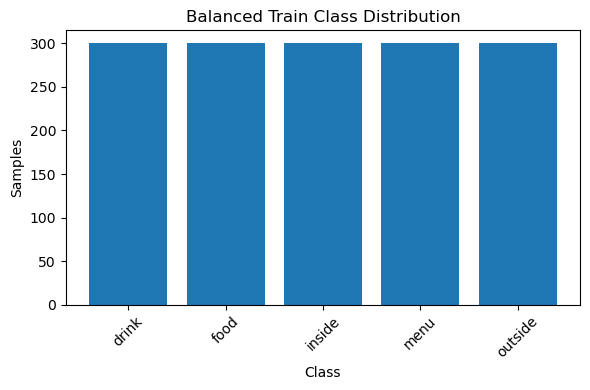

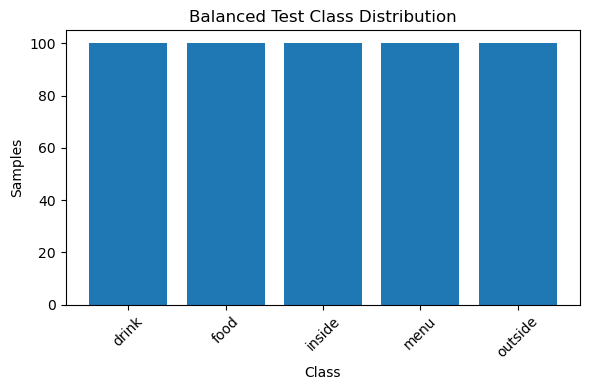

In [3]:
# ------------------- Plot Class Distribution -------------------

def plot_distribution(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())
    plt.figure(figsize=(6, 4))
    plt.bar(classes, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_distribution(train_counts, "Balanced Train Class Distribution")
plot_distribution(test_counts, "Balanced Test Class Distribution")

In [18]:
# ------------------- Load Data -------------------

train_dir = r"D:\balanced\train"
test_dir = r"D:\balanced\test"
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


Model Building 

In [19]:
# ------------------- Build Model (Train All Layers) -------------------

def build_vgg_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    
    # Train all layers
    for layer in base_model.layers:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

model = build_vgg_model(num_classes=5)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 256)                 │         131,3

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 14,847,301 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

Model training 

In [21]:
# ------------------- Train Model -------------------

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=2,
    callbacks=callbacks
)

Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 594s 13s/step - accuracy: 0.2548 - loss: 1.6151 - val_accuracy: 0.3640 - val_loss: 1.4561
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 579s 12s/step - accuracy: 0.3239 - loss: 1.4369 - val_accuracy: 0.4680 - val_loss: 1.3031


Plot for Confusion Matrix , ROC Curve & Train vs Val Accuracy-Loss 

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ------------------ Predict on Test Data ------------------
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step


[[ 3 29 39 23  6]
 [ 3 28 33 34  2]
 [ 4 36 31 25  4]
 [ 1 26 33 33  7]
 [ 3 30 31 32  4]]


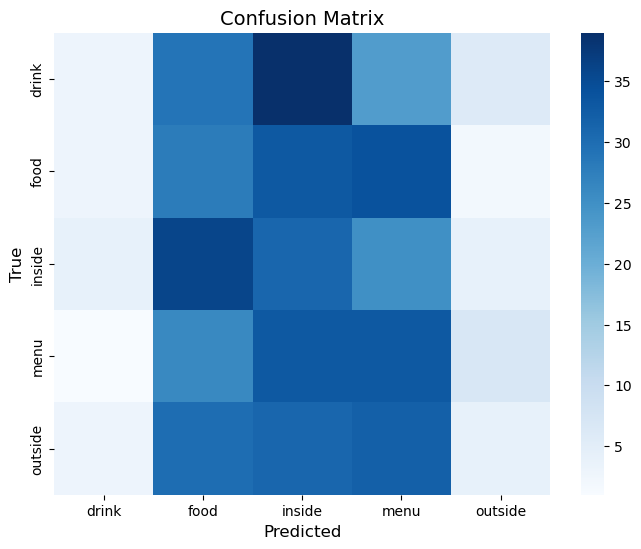

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm ,fmt="d", cmap="Blues",
                 xticklabels=class_names,
                 yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

print(cm)

plt.show()


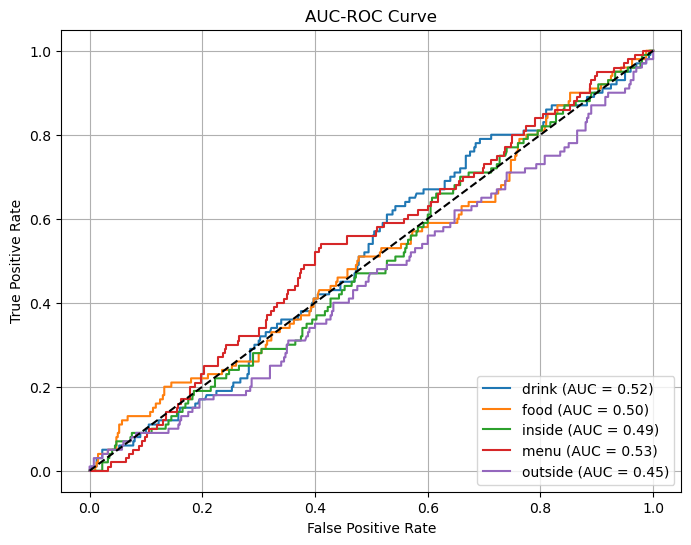

In [33]:
# ------------------ ROC Curve and AUC ------------------
# One-hot true labels for ROC
from sklearn.preprocessing import label_binarize
y_true_onehot = label_binarize(y_true, classes=list(range(len(class_names))))

plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Overall AUC Score: 0.4997


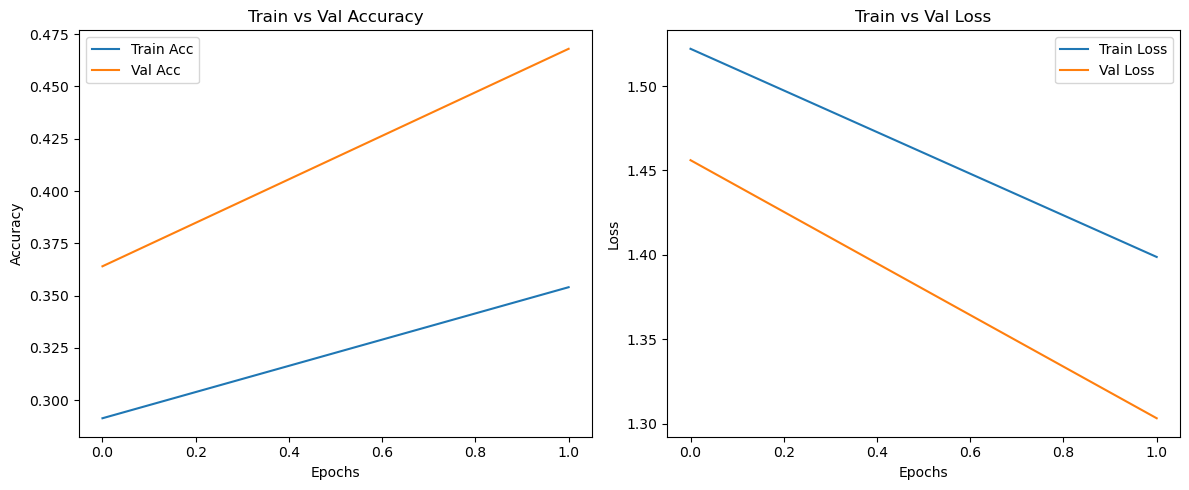

In [34]:
# ------------------ Overall AUC Score ------------------
from sklearn.metrics import roc_auc_score
overall_auc = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')
print(f"Overall AUC Score: {overall_auc:.4f}")

# ------------------ Accuracy and Loss Curves ------------------
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Train vs Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Train vs Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Model Saving 

In [35]:
model.save("D:/vgg_base.keras")
print("saved")

saved


Model Tuning 

In [37]:
import os
from tensorflow.keras.models import load_model

save_dir = 'D:/tuned_models'
os.makedirs(save_dir, exist_ok=True)

best_val_acc = 0
best_config = None
best_model_path = None

# Hyperparameter search space
lr_list = [1e-3, 1e-4]
dense_units_list = [128, 256]
dropout_list = [0.3, 0.5]

for lr in lr_list:
    for dense_units in dense_units_list:
        for drop in dropout_list:
            print(f"\nTraining: LR={lr}, Dense={dense_units}, Dropout={drop}")

            base_model = load_model("D:/vgg_base.keras")

            x = base_model.layers[-4].output
            x = Dense(dense_units, activation='relu')(x)
            x = Dropout(drop)(x)
            output = Dense(5, activation='softmax')(x)
            tuned_model = Model(inputs=base_model.input, outputs=output)

            tuned_model.compile(
                optimizer=Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            # Save in custom path
            model_name = os.path.join(save_dir, f"vgg_tuned_lr{lr}_dense{dense_units}_drop{int(drop*100)}.keras")

            history = tuned_model.fit(
                train_gen,
                validation_data=val_gen,
                epochs=2,
                callbacks=[
                    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
                    ModelCheckpoint(model_name, save_best_only=True)
                ],
                verbose=1
            )

            val_acc = max(history.history['val_accuracy'])
            print(f"Finished: val_accuracy = {val_acc:.4f}")
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_config = (lr, dense_units, drop)
                best_model_path = model_name

print("\nBest Model Config:")
print(f"Learning Rate: {best_config[0]}")
print(f"Dense Units: {best_config[1]}")
print(f"Dropout: {best_config[2]}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Saved Model: {best_model_path}")


Training: LR=0.001, Dense=128, Dropout=0.3
Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 536s 11s/step - accuracy: 0.1961 - loss: 1.7385 - val_accuracy: 0.2000 - val_loss: 1.6112
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 528s 11s/step - accuracy: 0.2066 - loss: 1.6136 - val_accuracy: 0.2640 - val_loss: 1.6050
Finished: val_accuracy = 0.2640

Training: LR=0.001, Dense=128, Dropout=0.5
Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 533s 11s/step - accuracy: 0.2147 - loss: 1.6975 - val_accuracy: 0.2000 - val_loss: 1.6064
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 521s 11s/step - accuracy: 0.2134 - loss: 1.6073 - val_accuracy: 0.1980 - val_loss: 1.6124
Finished: val_accuracy = 0.2000

Training: LR=0.001, Dense=256, Dropout=0.3
Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 537s 11s/step - accuracy: 0.1998 - loss: 1.8503 - val_accuracy: 0.2000 - val_loss: 1.6118
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 529s 11s/step - accuracy: 0.2151 - loss: 1.6083 - val_accuracy: 0.2000 - val_loss: 1.6093
Finished: val_accuracy = 0.2000

Training:

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 529s 11s/step - accuracy: 0.1802 - loss: 1.6739 - val_accuracy: 0.2280 - val_loss: 1.6061
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 524s 11s/step - accuracy: 0.2477 - loss: 1.5955 - val_accuracy: 0.3220 - val_loss: 1.4754
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 520s 11s/step - accuracy: 0.3627 - loss: 1.4537 - val_accuracy: 0.5260 - val_loss: 1.1729
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 522s 11s/step - accuracy: 0.4632 - loss: 1.2451 - val_accuracy: 0.4640 - val_loss: 1.2568
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 527s 11s/step - accuracy: 0.5308 - loss: 1.1848 - val_accuracy: 0.6060 - val_loss: 0.9932
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step


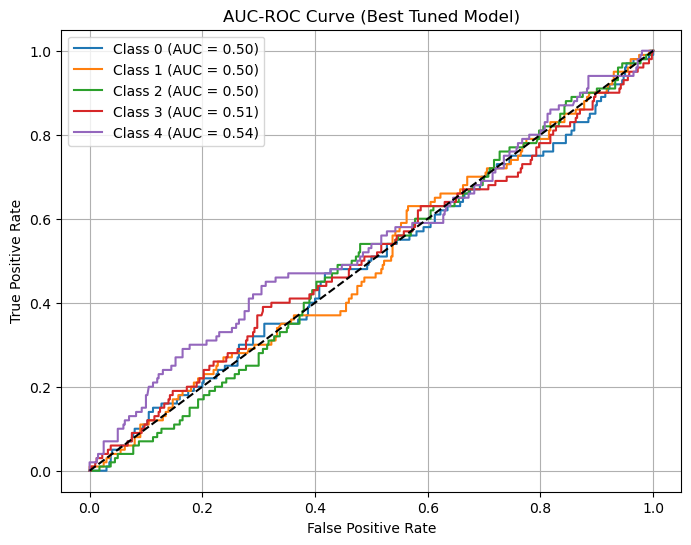

Overall Macro AUC Score: 0.5086


In [38]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Step 1: Extract Best Parameters ----------------
lr, dense_units, drop = best_config  # From your previous tuning code

# ---------------- Step 2: Rebuild & Train the Model ----------------
base_model = load_model("D:/vgg_base.keras")

x = base_model.layers[-4].output
x = Dense(dense_units, activation='relu')(x)
x = Dropout(drop)(x)
output = Dense(5, activation='softmax')(x)

final_model = Model(inputs=base_model.input, outputs=output)

final_model.compile(
    optimizer=Adam(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = final_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[
        EarlyStopping(patience=2, restore_best_weights=True, monitor='val_accuracy')
    ],
    verbose=1
)

# ---------------- Step 3: Predict on Validation Data ----------------
val_gen.reset()
y_probs = final_model.predict(val_gen, verbose=1)
y_preds = np.argmax(y_probs, axis=1)
y_true = val_gen.classes

# ---------------- Step 4: AUC Evaluation ----------------
y_true_bin = label_binarize(y_true, classes=list(range(5)))

plt.figure(figsize=(8, 6))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("AUC-ROC Curve (Best Tuned Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- Step 5: Macro AUC ----------------
overall_auc = roc_auc_score(y_true_bin, y_probs, average='macro')
print(f"Overall Macro AUC Score: {overall_auc:.4f}")

In [40]:
!pip install lime scikit-image

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 976ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 967ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/ste

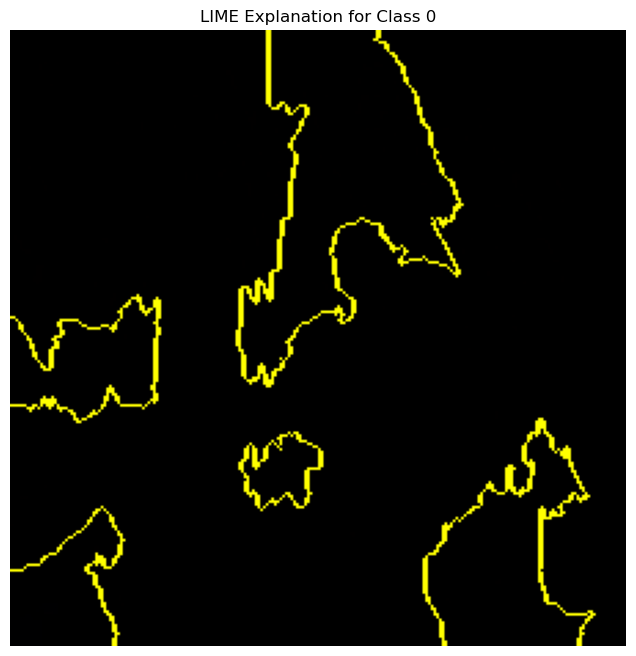

In [44]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from skimage.segmentation import mark_boundaries
from lime.lime_image import LimeImageExplainer

# ---------------------- Load Trained Model ----------------------
model_path = 'D:/tuned_models/vgg_tuned_lr0.001_dense256_drop30.keras'  # Replace with your model
final_model = load_model(model_path)

# ---------------------- Choose a Test Image ----------------------
img_path = r"D:\Downloads\download.jpeg"  # Replace with actual test image

# ---------------------- Preprocess ----------------------
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    return img

image_np = preprocess_image(img_path)
image_batch = np.expand_dims(image_np, axis=0)

# ---------------------- Prediction Function ----------------------
def predict_fn(images):
    images = np.array(images)
    return final_model.predict(images)

# ---------------------- Explain with LIME ----------------------
explainer = LimeImageExplainer()

explanation = explainer.explain_instance(
    image_np,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

top_label = explanation.top_labels[0]

# ✅ Call method from explanation object (no import)
temp, mask = explanation.get_image_and_mask(
    label=top_label,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation for Class {top_label}")
plt.axis('off')
plt.show()